In [9]:
import cv2
import matplotlib.pyplot as plt
import os
import random
import numpy as np
import pandas as pd
from glob import glob
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision.models import inception_v3
import torchvision.models as models
from torch import Tensor

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
from sklearn.model_selection import StratifiedKFold, train_test_split


class CFG:
    DATASET_PATH = "/kaggle/input/prdb-rice/Original_Images"
    SEARCH_ROOTS = [DATASET_PATH, "/kaggle/input"]
    IMG_EXTS = (".png", ".jpg", ".jpeg", ".bmp")
    IMG_SIZE = 299
    SEED = 42
    NUM_WORKERS = 2
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    SSL_BATCH = 64
    SSL_EPOCHS = 150
    SSL_LR = 3e-4
    SSL_WEIGHT_DECAY = 1e-4
    TEMP = 0.2
    PROJ_DIM = 128
    LP_BATCH = 32
    LP_EPOCHS = 30
    LP_LR = 1e-3
    USE_FOCAL = False
    VAL_SIZE = 0.2
    TEST_SIZE = 0.1
    ROI_CROP_PROB = 0.0
    INTENSITY_GAIN_RANGE = (0.8, 1.2)
    INTENSITY_BIAS_RANGE = (-15, 15)
    BG_ERASE_PROB = 0.4
    BG_ERASE_RATE = 0.1
    OUT_DIR = "/kaggle/working/prdb_ssl"
    
    SSL_CKPT_INCEPTION = "ssl_backbone_inception.pth"
    LP_CKPT_INCEPTION = "lp_classifier_inception.pth"
    

os.makedirs(CFG.OUT_DIR, exist_ok=True)

def set_seed(seed=CFG.SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed()


In [10]:
# 1. Class Map for PRDB
CLASS_MAP = {
    "Aush": 0,
    "Beroi": 1,
    "BR-28": 2,
    "BR-29": 3,
    "Chinigura": 4,
    "Ghee Bhog": 5,
    "Katari Najir": 6,
    "Katari Siddho": 7,
    "Miniket": 8,
    "Swarna":9
}
INV_CLASS = {v: k for k, v in CLASS_MAP.items()}

PRDB_ROOT = "/kaggle/input/prdb-rice/Original_Images"

assert os.path.exists(PRDB_ROOT), "ERROR: PRDB dataset path does NOT exist!"
print("[INFO] Using PRDB root:", PRDB_ROOT)


# 2. Build Image Index
def build_index(root=PRDB_ROOT):
    rows = []
    for cls, lbl in CLASS_MAP.items():
        cls_folder = os.path.join(root, cls)
        for img_path in glob(os.path.join(cls_folder, "*")):
            if not img_path.lower().endswith(CFG.IMG_EXTS):
                continue
            rows.append({"image": img_path, "label": lbl, "cls": cls})
    df = pd.DataFrame(rows)
    print("Counts per class:\n", df["cls"].value_counts())
    return df

df_all = build_index(PRDB_ROOT)


[INFO] Using PRDB root: /kaggle/input/prdb-rice/Original_Images
Counts per class:
 cls
Aush             200
Beroi            200
BR-28            200
BR-29            200
Chinigura        200
Ghee Bhog        200
Katari Najir     200
Katari Siddho    200
Miniket          200
Swarna           200
Name: count, dtype: int64


In [11]:
import shutil
import os
from sklearn.model_selection import train_test_split

# Base directory for split data
base_split_dir = os.path.join(CFG.OUT_DIR, "split_data")
train_dir = os.path.join(base_split_dir, "train")
val_dir = os.path.join(base_split_dir, "val")
test_dir = os.path.join(base_split_dir, "test")

# Create base split directories
os.makedirs(train_dir, exist_ok=True)
os.makedirs(val_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

print("Splitting dataset into train (80%), val (10% of training), test (20%) for each class...")

for class_name, class_label in CLASS_MAP.items():
    # Filter images of current class
    class_df = df_all[df_all['cls'] == class_name]
    images_full_paths = class_df['image'].tolist()

    if not images_full_paths:
        print(f"[WARN] No images found for class {class_name}. Skipping.")
        continue

    # First split: train 80%, test 20%
    train_imgs, test_imgs = train_test_split(
        images_full_paths, test_size=0.20, random_state=CFG.SEED
    )

    # Second split: allocate 10% of training as validation
    val_size = 0.10  # 10% of training
    train_imgs, val_imgs = train_test_split(
        train_imgs, test_size=val_size, random_state=CFG.SEED
    )

    # Create class folders
    for d in [train_dir, val_dir, test_dir]:
        os.makedirs(os.path.join(d, class_name), exist_ok=True)

    # Copy files
    for img_path in train_imgs:
        shutil.copy(img_path, os.path.join(train_dir, class_name, os.path.basename(img_path)))
    for img_path in val_imgs:
        shutil.copy(img_path, os.path.join(val_dir, class_name, os.path.basename(img_path)))
    for img_path in test_imgs:
        shutil.copy(img_path, os.path.join(test_dir, class_name, os.path.basename(img_path)))

    print(f"{class_name}: Train={len(train_imgs)}, Val={len(val_imgs)}, Test={len(test_imgs)}")



Splitting dataset into train (80%), val (10% of training), test (20%) for each class...
Aush: Train=144, Val=16, Test=40
Beroi: Train=144, Val=16, Test=40
BR-28: Train=144, Val=16, Test=40
BR-29: Train=144, Val=16, Test=40
Chinigura: Train=144, Val=16, Test=40
Ghee Bhog: Train=144, Val=16, Test=40
Katari Najir: Train=144, Val=16, Test=40
Katari Siddho: Train=144, Val=16, Test=40
Miniket: Train=144, Val=16, Test=40
Swarna: Train=144, Val=16, Test=40


In [12]:
import pandas as pd

train_dfs = []

for cls in df_all['cls'].unique():
    cls_rows = df_all[df_all['cls'] == cls].head(144)  # select first 144 as train
    train_dfs.append(cls_rows)

# Combine all class train rows
train_df = pd.concat(train_dfs).reset_index(drop=True)

# Create unlabeled train dataset
unlabeled_train_df = train_df.drop(columns=['label', 'cls'], errors='ignore')

# Shuffle
unlabeled_train_df = unlabeled_train_df.sample(frac=1, random_state=CFG.SEED).reset_index(drop=True)

print("Combined unlabeled train data created.")
display(unlabeled_train_df.head())


Combined unlabeled train data created.


,image
0,/kaggle/input/prdb-rice/Original_Images/Beroi/...
1,/kaggle/input/prdb-rice/Original_Images/Chinig...
2,/kaggle/input/prdb-rice/Original_Images/BR-29/...
3,/kaggle/input/prdb-rice/Original_Images/Aush/p...
4,/kaggle/input/prdb-rice/Original_Images/Chinig...


In [13]:
import torchvision.transforms as T
from torch.utils.data import Dataset
import cv2


# SSL Dataset ( Augmentation for Unlabeled Data)
class SSLDataset(Dataset):
    def __init__(self, df, transform=None, unlabeled=False, augment=True):
       
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.unlabeled = unlabeled
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.loc[idx, "image"]
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Apply augmentation
        if self.transform:
            if self.augment:
                v1 = self.transform(img)
                v2 = v1.clone()  #  augmented image
            else:
                v1 = self.transform(img)
                v2 = self.transform(img)
        else:
            import torchvision.transforms.functional as TF
            v1 = TF.to_tensor(img)
            v2 = v1.clone() if self.augment else TF.to_tensor(img)

        if self.unlabeled:
            return v1, v2
        else:
            label = self.df.loc[idx, "label"]
            return v1, v2, label

# ==============================
# SSL Transform
# ==============================
def get_ssl_transform():
    return T.Compose([
        T.ToPILImage(),
        T.RandomResizedCrop(CFG.IMG_SIZE, scale=(0.5, 1.0), ratio=(0.8, 1.2)),
        T.RandomHorizontalFlip(p=0.5),
        T.RandomVerticalFlip(p=0.5),
        T.RandomRotation(degrees=20),
        T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.02),
        T.RandomGrayscale(p=0.2),
        # Convert to tensor
        T.ToTensor(),
        # Tensor-only transforms
        T.GaussianBlur(kernel_size=(7, 15), sigma=(0.1, 2.0)),
        T.RandomErasing(p=0.2, scale=(0.02, 0.15), ratio=(0.3, 3.3), value='random')
    ])


# ==============================
# Create the dataset
# ==============================
ssl_transform = get_ssl_transform()
unlabeled_dataset = SSLDataset(
    unlabeled_train_df, 
    transform=ssl_transform, 
    unlabeled=True, 
    augment=True  # ensures both views are identical
)


In [14]:
import os
from tqdm import tqdm
import torchvision.utils as vutils

# Base directory to save augmented images
aug_save_dir = os.path.join(CFG.OUT_DIR, "augmented")
os.makedirs(aug_save_dir, exist_ok=True)

# Optionally, save each image in a separate folder
for idx in range(len(unlabeled_dataset)):
    v1, v2 = unlabeled_dataset[idx]  # augmented views

    # Convert tensors to PIL images for saving
    from torchvision.transforms.functional import to_pil_image
    img1 = to_pil_image(v1)
    img2 = to_pil_image(v2)

    # Create unique filenames
    base_name = f"aug_{idx:04d}"
    img1.save(os.path.join(aug_save_dir, f"{base_name}_v1.png"))
    img2.save(os.path.join(aug_save_dir, f"{base_name}_v2.png"))

print(f"Saved {len(unlabeled_dataset)*2} augmented images in {aug_save_dir}")


Saved 2880 augmented images in /kaggle/working/prdb_ssl/augmented


In [15]:
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from torchvision import transforms

# Transform for SSL
ssl_transform = get_ssl_transform()

train_dataset = ImageFolder(root=os.path.join(CFG.OUT_DIR, "split_data/train"), transform=ssl_transform)
val_dataset   = ImageFolder(root=os.path.join(CFG.OUT_DIR, "split_data/val"), transform=ssl_transform)
test_dataset  = ImageFolder(root=os.path.join(CFG.OUT_DIR, "split_data/test"), transform=ssl_transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=CFG.NUM_WORKERS)
val_loader   = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=CFG.NUM_WORKERS)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=CFG.NUM_WORKERS)


In [16]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from tqdm import tqdm
import os
import time
import torchvision.models as models


# Config
class CFG:
    OUT_DIR = "./prdb_ssl"
os.makedirs(CFG.OUT_DIR, exist_ok=True)


# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


# Hyperparameters
ssl_batch = 16
ssl_epochs = 120         # CPU-friendly
learning_rate = 3e-4
weight_decay = 1e-4
temperature = 0.2
proj_dim = 128
hidden_dim = 512
out_dir = CFG.OUT_DIR


# DenseNet-121 Backbone + Projection Head
class DenseNet121WithProj(nn.Module):
    def __init__(self, proj_dim=128, hidden_dim=512, pretrained=False):
        super().__init__()
        self.backbone = models.densenet121(weights=None if not pretrained else models.DenseNet121_Weights.DEFAULT)
        self.backbone.classifier = nn.Identity()  # remove default classifier
        feat_dim = 1024  # DenseNet-121 feature dimension

        # small MLP projection head
        self.proj_head = nn.Sequential(
            nn.Linear(feat_dim, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, proj_dim)
        )

    def forward(self, x):
        features = self.backbone.features(x)
        out = F.relu(features, inplace=True)
        out = F.adaptive_avg_pool2d(out, (1, 1))
        out = torch.flatten(out, 1)
        z = self.proj_head(out)
        return out, z


# Instantiate model
model = DenseNet121WithProj(proj_dim=proj_dim, hidden_dim=hidden_dim)
model.to(device)

# Optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)


# NT-Xent Loss
def nt_xent_loss(z1, z2, temperature=0.2):
    N = z1.size(0)
    z = torch.cat([z1, z2], dim=0)
    z = F.normalize(z, dim=1)
    sim = torch.matmul(z, z.T)
    exp_sim = torch.exp(sim / temperature)
    mask = (~torch.eye(2*N, dtype=torch.bool)).to(device)
    exp_sim = exp_sim * mask
    pos_sim = torch.cat([torch.diag(sim, N), torch.diag(sim, -N)], dim=0)
    numerator = torch.exp(pos_sim / temperature)
    denom = exp_sim.sum(dim=1)
    loss = -torch.log(numerator / denom)
    return loss.mean()


# DataLoader (replace with your SSLDataset)
ssl_loader = DataLoader(
    unlabeled_dataset,  # make sure this is defined
    batch_size=ssl_batch,
    shuffle=True,
    num_workers=0
)


# Training Loop
best_loss = float('inf')
print("Starting SSL pretraining with DenseNet-121 on CPU...")

for epoch in range(1, ssl_epochs+1):
    model.train()
    epoch_loss = 0.0
    t0 = time.time()
    pbar = tqdm(ssl_loader, desc=f"Epoch {epoch}/{ssl_epochs}", leave=False)
    
    for v1, v2 in pbar:
        v1 = v1.to(device)
        v2 = v2.to(device)

        _, z1 = model(v1)
        _, z2 = model(v2)

        loss = nt_xent_loss(z1, z2, temperature=temperature)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        pbar.set_postfix({'loss': f"{loss.item():.4f}"})

    epoch_loss /= len(ssl_loader)
    t1 = time.time()
    print(f"Epoch {epoch:03d} avg_loss={epoch_loss:.4f} time={(t1-t0):.1f}s")

    if epoch_loss < best_loss:
        best_loss = epoch_loss
        best_ckpt = os.path.join(out_dir, "ssl_best_densenet121.pth")
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': epoch_loss
        }, best_ckpt)
        print(f"  -> New best saved: {best_ckpt}")


# Freeze Encoder + Save
class EncoderOnly(nn.Module):
    def __init__(self, backbone_with_proj):
        super().__init__()
        self.encoder = backbone_with_proj.backbone

    def forward(self, x):
        features = self.encoder.features(x)
        out = F.relu(features, inplace=True)
        out = F.adaptive_avg_pool2d(out, (1, 1))
        out = torch.flatten(out, 1)
        return out

encoder_only = EncoderOnly(model)
encoder_only.to(device)
for p in encoder_only.parameters():
    p.requires_grad = False

encoder_path = os.path.join(out_dir, "encoder_frozen_densenet121.pth")
torch.save(encoder_only.state_dict(), encoder_path)
print(f"Saved frozen encoder: {encoder_path}")


Using device: cuda
Starting SSL pretraining with DenseNet-121 on CPU...


Epoch 001 avg_loss=0.5041 time=69.4s
  -> New best saved: ./prdb_ssl/ssl_best_densenet121.pth


Epoch 002 avg_loss=0.3200 time=69.7s
  -> New best saved: ./prdb_ssl/ssl_best_densenet121.pth


Epoch 003 avg_loss=0.2785 time=69.5s
  -> New best saved: ./prdb_ssl/ssl_best_densenet121.pth


Epoch 004 avg_loss=0.3001 time=69.5s


...

Epoch 116 avg_loss=0.2284 time=70.0s


Epoch 117 avg_loss=0.2151 time=69.8s


Epoch 118 avg_loss=0.2345 time=69.4s


Epoch 119 avg_loss=0.2752 time=69.1s


Epoch 120 avg_loss=0.2408 time=69.9s
Saved frozen encoder: ./prdb_ssl/encoder_frozen_densenet121.pth


In [19]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
import torchvision.transforms as T
from tqdm import tqdm
from sklearn.metrics import classification_report
import numpy as np
import os

# ==============================
# Config
# ==============================
class CFG:
    OUT_DIR = "./prdb_ssl"
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    LP_BATCH = 32
    LP_EPOCHS = 40
    LP_LR = 1e-3
    NUM_CLASSES = 10
    IMG_SIZE = 224
    NUM_WORKERS = 2

os.makedirs(CFG.OUT_DIR, exist_ok=True)
device = CFG.DEVICE
print("[INFO] Using device:", device)

# ==============================
# Dataset / DataLoader (VAL dataset is used for LP training)
# ==============================
lp_transform = T.Compose([
    T.Resize((CFG.IMG_SIZE, CFG.IMG_SIZE)),
    T.ToTensor(),
])

val_dataset = ImageFolder(root=os.path.join(CFG.OUT_DIR, "split_data/val"), transform=lp_transform)
val_loader  = DataLoader(val_dataset, batch_size=CFG.LP_BATCH, shuffle=True, num_workers=CFG.NUM_WORKERS)

# ==============================
# Encoder + Projection Head (already trained)
# ==============================
class DenseNet121WithProj(nn.Module):
    def __init__(self, proj_dim=128, hidden_dim=512, pretrained=False):
        super().__init__()
        from torchvision.models import densenet121
        self.backbone = densenet121(weights=None)
        self.backbone.classifier = nn.Identity()
        self.proj_head = nn.Sequential(
            nn.Linear(1024, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, proj_dim)
        )

    def forward(self, x):
        features = self.backbone.features(x)
        out = torch.relu(features)
        out = torch.nn.functional.adaptive_avg_pool2d(out, (1,1))
        out = torch.flatten(out, 1)
        z = self.proj_head(out)
        return out, z

class EncoderOnly(nn.Module):
    def __init__(self, backbone):
        super().__init__()
        self.encoder = backbone.backbone
        for p in self.encoder.parameters():
            p.requires_grad = False

    def forward(self, x):
        with torch.no_grad():
            features = self.encoder.features(x)
            out = torch.relu(features)
            out = torch.nn.functional.adaptive_avg_pool2d(out, (1,1))
            out = torch.flatten(out, 1)
        return out  # (batch_size, 1024)


# Load frozen encoder
encoder_only = EncoderOnly(DenseNet121WithProj())
encoder_only.load_state_dict(torch.load(os.path.join(CFG.OUT_DIR, "encoder_frozen_densenet121.pth"), map_location=device))
encoder_only.to(device)
encoder_only.eval()

# ==============================
# Linear Probe Model with Extra Frozen Layer
# ==============================
class LinearProbeWithExtraFreeze(nn.Module):
    def __init__(self, encoder, feature_dim=1024, num_classes=CFG.NUM_CLASSES):
        super().__init__()
        self.encoder = encoder

        for p in self.encoder.parameters():
            p.requires_grad = False

        self.fc1 = nn.Linear(feature_dim, 512)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(512, num_classes)

        # Freeze extra layer
        for p in self.fc1.parameters():
            p.requires_grad = False

    def forward(self, x):
        with torch.no_grad():
            feats = self.encoder(x)
        x = self.fc1(feats)
        x = self.relu(x)
        x = self.fc2(x)
        return x

model_lp = LinearProbeWithExtraFreeze(encoder_only).to(device)

# ==============================
# Loss + Optimizer
# ==============================
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model_lp.parameters()), lr=CFG.LP_LR)

# ==============================
# Training Loop
# ==============================
best_loss = float('inf')

for epoch in range(1, CFG.LP_EPOCHS + 1):
    model_lp.train()
    running_loss = 0
    correct, total = 0, 0

    pbar = tqdm(val_loader, desc=f"LP Epoch {epoch}/{CFG.LP_EPOCHS}", leave=False)

    for imgs, labels in pbar:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model_lp(imgs)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        pbar.set_postfix({"loss": f"{loss.item():.4f}"})

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    print(f"Epoch {epoch:03d} | Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f}")

    if epoch_loss < best_loss:
        best_loss = epoch_loss
        ckpt_path = os.path.join(CFG.OUT_DIR, "linear_probe_extra_frozen.pth")
        torch.save(model_lp.state_dict(), ckpt_path)
        print(f"  -> Saved best LP model: {ckpt_path}")

# ==============================
# Final Evaluation (same val set)
# ==============================
model_lp.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(device)
        outputs = model_lp(imgs)
        preds = outputs.argmax(1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

acc = (all_preds == all_labels).mean()
print(f"\n[FINAL VAL] Accuracy: {acc:.4f}\n")
print("Classification Report:")
print(classification_report(all_labels, all_preds))


[INFO] Using device: cuda


Epoch 001 | Loss: 2.3041 | Acc: 0.1375
  -> Saved best LP model: ./prdb_ssl/linear_probe_extra_frozen.pth


Epoch 002 | Loss: 2.2397 | Acc: 0.3000
  -> Saved best LP model: ./prdb_ssl/linear_probe_extra_frozen.pth


Epoch 003 | Loss: 2.1889 | Acc: 0.4062
  -> Saved best LP model: ./prdb_ssl/linear_probe_extra_frozen.pth


Epoch 004 | Loss: 2.1323 | Acc: 0.4188
  -> Saved best LP model: ./prdb_ssl/linear_probe_extra_frozen.pth


...

Epoch 037 | Loss: 1.3988 | Acc: 0.6312
  -> Saved best LP model: ./prdb_ssl/linear_probe_extra_frozen.pth


Epoch 038 | Loss: 1.4994 | Acc: 0.5750


Epoch 039 | Loss: 1.4857 | Acc: 0.5375


Epoch 040 | Loss: 1.3934 | Acc: 0.6562
  -> Saved best LP model: ./prdb_ssl/linear_probe_extra_frozen.pth



[FINAL VAL] Accuracy: 0.6312

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.75      0.75        16
           1       0.71      0.62      0.67        16
           2       0.46      0.69      0.55        16
           3       0.71      0.75      0.73        16
           4       0.80      0.75      0.77        16
           5       0.42      0.31      0.36        16
           6       0.56      0.56      0.56        16
           7       0.62      0.62      0.62        16
           8       0.69      0.69      0.69        16
           9       0.64      0.56      0.60        16

    accuracy                           0.63       160
   macro avg       0.64      0.63      0.63       160
weighted avg       0.64      0.63      0.63       160



In [23]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
import torchvision.transforms as T
from tqdm import tqdm
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
import os
import numpy as np

# ==============================
# Config
# ==============================
class CFG:
    OUT_DIR = "./prdb_ssl"
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    LP_BATCH = 32
    LP_EPOCHS = 90
    LP_LR = 1e-3
    NUM_CLASSES = 10
    IMG_SIZE = 224
    NUM_WORKERS = 2

os.makedirs(CFG.OUT_DIR, exist_ok=True)
device = CFG.DEVICE
print("[INFO] Using device:", device)

# ==============================
# Dataset / DataLoader
# ==============================
lp_transform = T.Compose([
    T.Resize((CFG.IMG_SIZE, CFG.IMG_SIZE)),
    T.ToTensor(),
])

train_dataset = ImageFolder(root=os.path.join(CFG.OUT_DIR, "split_data/train"), transform=lp_transform)
val_dataset   = ImageFolder(root=os.path.join(CFG.OUT_DIR, "split_data/val"), transform=lp_transform)
test_dataset  = ImageFolder(root=os.path.join(CFG.OUT_DIR, "split_data/test"), transform=lp_transform)

train_loader = DataLoader(train_dataset, batch_size=CFG.LP_BATCH, shuffle=True, num_workers=CFG.NUM_WORKERS)
val_loader   = DataLoader(val_dataset, batch_size=CFG.LP_BATCH, shuffle=False, num_workers=CFG.NUM_WORKERS)
test_loader  = DataLoader(test_dataset, batch_size=CFG.LP_BATCH, shuffle=False, num_workers=CFG.NUM_WORKERS)

# ==============================
# Shallow MLP head on frozen encoder
# ==============================
class ShallowMLP(nn.Module):
    def __init__(self, encoder, feature_dim=1024, hidden_dim=512, num_classes=CFG.NUM_CLASSES):
        super().__init__()
        self.encoder = encoder
        for p in self.encoder.parameters():
            p.requires_grad = False  # freeze encoder

        self.fc1 = nn.Linear(feature_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        with torch.no_grad():
            features = self.encoder(x)
        x = self.fc1(features)
        x = self.relu(x)
        x = self.fc2(x)
        return x

# Load frozen encoder
encoder_only = EncoderOnly(DenseNet121WithProj(proj_dim=128, hidden_dim=512))
encoder_only.load_state_dict(torch.load(os.path.join(CFG.OUT_DIR, "encoder_frozen_densenet121.pth"), map_location=device))
encoder_only = encoder_only.to(device)
encoder_only.eval()

# Instantiate model
model = ShallowMLP(encoder=encoder_only).to(device)

# ==============================
# Loss + Optimizer (only head trainable)
# ==============================
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=CFG.LP_LR)

# ==============================
# Training Loop (Linear probe style)
# ==============================
best_loss = float('inf')
for epoch in range(1, CFG.LP_EPOCHS+1):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    pbar = tqdm(train_loader, desc=f"LP Epoch {epoch}/{CFG.LP_EPOCHS}", leave=False)
    
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        pbar.set_postfix({'loss': f"{loss.item():.4f}"})
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    print(f"Epoch {epoch:03d}: Train Loss={epoch_loss:.4f}, Train Acc={epoch_acc:.4f}")

    # Save best model
    if epoch_loss < best_loss:
        best_loss = epoch_loss
        lp_ckpt = os.path.join(CFG.OUT_DIR, "shallow_mlp_lp_best.pth")
        torch.save(model.state_dict(), lp_ckpt)
        print(f"  -> Saved best Linear Probe model: {lp_ckpt}")

# ==============================
# Evaluation on Test Set
# ==============================
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1)
        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())

all_preds = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()

# Metrics
acc = (all_preds == all_labels).mean()
print(f"[TEST] Accuracy: {acc:.4f}\n")
print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=list(CLASS_MAP.keys())))



[INFO] Using device: cuda


Epoch 001: Train Loss=1.6467, Train Acc=0.4243
  -> Saved best Linear Probe model: ./prdb_ssl/shallow_mlp_lp_best.pth


Epoch 002: Train Loss=1.2648, Train Acc=0.5375
  -> Saved best Linear Probe model: ./prdb_ssl/shallow_mlp_lp_best.pth


Epoch 003: Train Loss=1.2534, Train Acc=0.5729
  -> Saved best Linear Probe model: ./prdb_ssl/shallow_mlp_lp_best.pth


Epoch 004: Train Loss=1.1386, Train Acc=0.5993
  -> Saved best Linear Probe model: ./prdb_ssl/shallow_mlp_lp_best.pth


...

Epoch 086: Train Loss=0.6031, Train Acc=0.7965


Epoch 087: Train Loss=0.5997, Train Acc=0.7951


Epoch 088: Train Loss=0.6573, Train Acc=0.7708


Epoch 089: Train Loss=0.6274, Train Acc=0.7896


Epoch 090: Train Loss=0.6209, Train Acc=0.7771
[TEST] Accuracy: 0.7450

Classification Report:
               precision    recall  f1-score   support

         Aush       0.95      0.93      0.94        40
        Beroi       0.69      0.62      0.66        40
        BR-28       0.40      0.47      0.44        40
        BR-29       0.89      0.82      0.86        40
    Chinigura       0.88      0.88      0.88        40
    Ghee Bhog       0.70      0.57      0.63        40
 Katari Najir       0.58      0.78      0.67        40
Katari Siddho       0.84      0.53      0.65        40
      Miniket       0.88      0.95      0.92        40
       Swarna       0.77      0.90      0.83        40

     accuracy                           0.74       400
    macro avg       0.76      0.74      0.74       400
 weighted avg       0.76      0.74      0.74       400



In [20]:
import torch
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
import torchvision.transforms as T
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np
import os


# Config
class CFG:
    OUT_DIR = "./prdb_ssl"
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    BATCH_SIZE = 32
    IMG_SIZE = 224

device = CFG.DEVICE
print("[INFO] Using device:", device)


# Dataset / DataLoader
transform = T.Compose([
    T.Resize((CFG.IMG_SIZE, CFG.IMG_SIZE)),
    T.ToTensor(),
])

train_dataset = ImageFolder(root=os.path.join(CFG.OUT_DIR, "split_data/train"), transform=transform)
val_dataset   = ImageFolder(root=os.path.join(CFG.OUT_DIR, "split_data/val"), transform=transform)
test_dataset  = ImageFolder(root=os.path.join(CFG.OUT_DIR, "split_data/test"), transform=transform)

train_loader = DataLoader(train_dataset, batch_size=CFG.BATCH_SIZE, shuffle=False)
val_loader   = DataLoader(val_dataset, batch_size=CFG.BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=CFG.BATCH_SIZE, shuffle=False)


# Load frozen encoder
encoder_only = EncoderOnly(DenseNet121WithProj(proj_dim=128, hidden_dim=512))
encoder_only.load_state_dict(torch.load(os.path.join(CFG.OUT_DIR, "encoder_frozen_densenet121.pth"), map_location=device))
encoder_only = encoder_only.to(device)
encoder_only.eval()


# Extract features
def extract_features(loader, encoder):
    features_list, labels_list = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            feats = encoder(imgs)
            features_list.append(feats.cpu().numpy())
            labels_list.append(labels.numpy())
    X = np.vstack(features_list)
    y = np.concatenate(labels_list)
    return X, y

print("[INFO] Extracting features...")
X_train, y_train = extract_features(train_loader, encoder_only)
X_val, y_val     = extract_features(val_loader, encoder_only)
X_test, y_test   = extract_features(test_loader, encoder_only)


# Train SVM on frozen features
print("[INFO] Training SVM classifier...")
svm_clf = SVC(kernel='linear', C=1.0)  # linear kernel SVM
svm_clf.fit(X_train, y_train)

# Evaluate on Test Set
y_pred = svm_clf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"[TEST] Accuracy: {acc:.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=list(CLASS_MAP.keys())))



[INFO] Using device: cuda
[INFO] Extracting features...
[INFO] Training SVM classifier...
[TEST] Accuracy: 0.7125
Classification Report:
               precision    recall  f1-score   support

         Aush       0.70      0.57      0.63        40
        Beroi       0.75      0.68      0.71        40
        BR-28       0.57      0.60      0.59        40
        BR-29       0.67      0.78      0.72        40
    Chinigura       0.85      0.97      0.91        40
    Ghee Bhog       0.79      0.78      0.78        40
 Katari Najir       0.42      0.40      0.41        40
Katari Siddho       0.65      0.65      0.65        40
      Miniket       0.94      0.85      0.89        40
       Swarna       0.77      0.85      0.81        40

     accuracy                           0.71       400
    macro avg       0.71      0.71      0.71       400
 weighted avg       0.71      0.71      0.71       400



In [21]:
import torch
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
import torchvision.transforms as T
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np
import os


# Config
class CFG:
    OUT_DIR = "./prdb_ssl"
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    BATCH_SIZE = 32
    IMG_SIZE = 224

device = CFG.DEVICE
print("[INFO] Using device:", device)


# Dataset / DataLoader
transform = T.Compose([
    T.Resize((CFG.IMG_SIZE, CFG.IMG_SIZE)),
    T.ToTensor(),
])

train_dataset = ImageFolder(root=os.path.join(CFG.OUT_DIR, "split_data/train"), transform=transform)
val_dataset   = ImageFolder(root=os.path.join(CFG.OUT_DIR, "split_data/val"), transform=transform)
test_dataset  = ImageFolder(root=os.path.join(CFG.OUT_DIR, "split_data/test"), transform=transform)

train_loader = DataLoader(train_dataset, batch_size=CFG.BATCH_SIZE, shuffle=False)
val_loader   = DataLoader(val_dataset, batch_size=CFG.BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=CFG.BATCH_SIZE, shuffle=False)


# Load frozen encoder
encoder_only = EncoderOnly(DenseNet121WithProj(proj_dim=128, hidden_dim=512))
encoder_only.load_state_dict(torch.load(os.path.join(CFG.OUT_DIR, "encoder_frozen_densenet121.pth"), map_location=device))
encoder_only = encoder_only.to(device)
encoder_only.eval()


# Extract features
def extract_features(loader, encoder):
    features_list, labels_list = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            feats = encoder(imgs)
            features_list.append(feats.cpu().numpy())
            labels_list.append(labels.numpy())
    X = np.vstack(features_list)
    y = np.concatenate(labels_list)
    return X, y

print("[INFO] Extracting features...")
X_train, y_train = extract_features(train_loader, encoder_only)
X_val, y_val     = extract_features(val_loader, encoder_only)
X_test, y_test   = extract_features(test_loader, encoder_only)


# Train Decision Tree on frozen features
print("[INFO] Training Decision Tree classifier...")
dt_clf = DecisionTreeClassifier(max_depth=10, random_state=42)  # shallow tree
dt_clf.fit(X_train, y_train)


# Evaluate on Test Set
y_pred = dt_clf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"[TEST] Accuracy: {acc:.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=list(CLASS_MAP.keys())))



[INFO] Using device: cuda
[INFO] Extracting features...
[INFO] Training Decision Tree classifier...
[TEST] Accuracy: 0.6050
Classification Report:
               precision    recall  f1-score   support

         Aush       0.52      0.40      0.45        40
        Beroi       0.63      0.55      0.59        40
        BR-28       0.46      0.55      0.50        40
        BR-29       0.61      0.70      0.65        40
    Chinigura       0.80      0.80      0.80        40
    Ghee Bhog       0.66      0.68      0.67        40
 Katari Najir       0.23      0.17      0.20        40
Katari Siddho       0.55      0.68      0.61        40
      Miniket       0.94      0.85      0.89        40
       Swarna       0.61      0.68      0.64        40

     accuracy                           0.60       400
    macro avg       0.60      0.60      0.60       400
 weighted avg       0.60      0.60      0.60       400



In [22]:
import torch
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
import torchvision.transforms as T
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np
import os


# Config
class CFG:
    OUT_DIR = "./prdb_ssl"
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    BATCH_SIZE = 32
    IMG_SIZE = 224

device = CFG.DEVICE
print("[INFO] Using device:", device)


# Dataset / DataLoader
transform = T.Compose([
    T.Resize((CFG.IMG_SIZE, CFG.IMG_SIZE)),
    T.ToTensor(),
])

train_dataset = ImageFolder(root=os.path.join(CFG.OUT_DIR, "split_data/train"), transform=transform)
val_dataset   = ImageFolder(root=os.path.join(CFG.OUT_DIR, "split_data/val"), transform=transform)
test_dataset  = ImageFolder(root=os.path.join(CFG.OUT_DIR, "split_data/test"), transform=transform)

train_loader = DataLoader(train_dataset, batch_size=CFG.BATCH_SIZE, shuffle=False)
val_loader   = DataLoader(val_dataset, batch_size=CFG.BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=CFG.BATCH_SIZE, shuffle=False)


# Load frozen encoder
encoder_only = EncoderOnly(DenseNet121WithProj(proj_dim=128, hidden_dim=512))
encoder_only.load_state_dict(torch.load(os.path.join(CFG.OUT_DIR, "encoder_frozen_densenet121.pth"), map_location=device))
encoder_only = encoder_only.to(device)
encoder_only.eval()


# Extract features
def extract_features(loader, encoder):
    features_list, labels_list = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            feats = encoder(imgs)
            features_list.append(feats.cpu().numpy())
            labels_list.append(labels.numpy())
    X = np.vstack(features_list)
    y = np.concatenate(labels_list)
    return X, y

print("[INFO] Extracting features...")
X_train, y_train = extract_features(train_loader, encoder_only)
X_val, y_val     = extract_features(val_loader, encoder_only)
X_test, y_test   = extract_features(test_loader, encoder_only)


# Train Random Forest on frozen features
print("[INFO] Training Random Forest classifier...")
rf_clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15, 
    random_state=42,
    n_jobs=-1
)
rf_clf.fit(X_train, y_train)


# Evaluate on Test Set
y_pred = rf_clf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"[TEST] Accuracy: {acc:.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=list(CLASS_MAP.keys())))



[INFO] Using device: cuda
[INFO] Extracting features...
[INFO] Training Random Forest classifier...
[TEST] Accuracy: 0.6975
Classification Report:
               precision    recall  f1-score   support

         Aush       0.81      0.62      0.70        40
        Beroi       0.74      0.70      0.72        40
        BR-28       0.59      0.60      0.59        40
        BR-29       0.67      0.80      0.73        40
    Chinigura       0.82      0.93      0.87        40
    Ghee Bhog       0.65      0.65      0.65        40
 Katari Najir       0.38      0.33      0.35        40
Katari Siddho       0.61      0.70      0.65        40
      Miniket       0.92      0.88      0.90        40
       Swarna       0.79      0.78      0.78        40

     accuracy                           0.70       400
    macro avg       0.70      0.70      0.69       400
 weighted avg       0.70      0.70      0.69       400



In [25]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
import torchvision.transforms as T
from tqdm import tqdm
import os
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


# Config
class CFG:
    OUT_DIR = "./prdb_ssl"
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    BATCH_SIZE = 16
    EPOCHS = 100          # adjust as needed
    LR = 1e-4
    NUM_CLASSES = 10
    IMG_SIZE = 224
    NUM_WORKERS = 2

os.makedirs(CFG.OUT_DIR, exist_ok=True)
device = CFG.DEVICE
print("[INFO] Using device:", device)


# Dataset / DataLoader
transform = T.Compose([
    T.Resize((CFG.IMG_SIZE, CFG.IMG_SIZE)),
    T.ToTensor(),
])

train_dataset = ImageFolder(root=os.path.join(CFG.OUT_DIR, "split_data/train"), transform=transform)
val_dataset   = ImageFolder(root=os.path.join(CFG.OUT_DIR, "split_data/val"), transform=transform)
test_dataset  = ImageFolder(root=os.path.join(CFG.OUT_DIR, "split_data/test"), transform=transform)

train_loader = DataLoader(train_dataset, batch_size=CFG.BATCH_SIZE, shuffle=True, num_workers=CFG.NUM_WORKERS)
val_loader   = DataLoader(val_dataset, batch_size=CFG.BATCH_SIZE, shuffle=False, num_workers=CFG.NUM_WORKERS)
test_loader  = DataLoader(test_dataset, batch_size=CFG.BATCH_SIZE, shuffle=False, num_workers=CFG.NUM_WORKERS)


# Full Model (encoder + classifier)
class FullFineTuneModel(nn.Module):
    def __init__(self, proj_dim=128, hidden_dim=512, num_classes=CFG.NUM_CLASSES):
        super().__init__()
        self.encoder = DenseNet121WithProj(proj_dim=proj_dim, hidden_dim=hidden_dim)
        self.fc = nn.Linear(1024, num_classes)  # DenseNet121 feature dim = 1024

    def forward(self, x):
        features, _ = self.encoder(x)
        out = self.fc(features)
        return out

model = FullFineTuneModel().to(device)

# Optionally, load pretrained frozen encoder weights
encoder_ckpt = os.path.join(CFG.OUT_DIR, "encoder_frozen_densenet121.pth")
if os.path.exists(encoder_ckpt):
    print("[INFO] Loading pretrained encoder weights for fine-tuning...")
    pretrained_dict = torch.load(encoder_ckpt, map_location=device)
    model.encoder.load_state_dict(pretrained_dict, strict=False)

# All parameters are trainable
for param in model.parameters():
    param.requires_grad = True


# Loss + Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=CFG.LR, weight_decay=1e-4)

# Training Loop
best_val_acc = 0.0
for epoch in range(1, CFG.EPOCHS+1):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    pbar = tqdm(train_loader, desc=f"Fine-tune Epoch {epoch}/{CFG.EPOCHS}", leave=False)
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        pbar.set_postfix({'loss': f"{loss.item():.4f}"})

    train_loss = running_loss / total
    train_acc = correct / total

    # Validation
    model.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            preds = outputs.argmax(dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)
    val_acc = val_correct / val_total

    print(f"Epoch {epoch:03d}: Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f}, Val Acc={val_acc:.4f}")

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        ft_ckpt = os.path.join(CFG.OUT_DIR, "full_finetune_densenet121.pth")
        torch.save(model.state_dict(), ft_ckpt)
        print(f"  -> Saved best fine-tuned model: {ft_ckpt}")


# Evaluate on Test Set
model.load_state_dict(torch.load(ft_ckpt, map_location=device))
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1)
        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())

all_preds = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
acc = accuracy_score(all_labels, all_preds)
print(f"[TEST] Accuracy: {acc:.4f}")
print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=list(CLASS_MAP.keys())))


[INFO] Using device: cuda
[INFO] Loading pretrained encoder weights for fine-tuning...


Epoch 001: Train Loss=1.3240, Train Acc=0.6243, Val Acc=0.6062
  -> Saved best fine-tuned model: ./prdb_ssl/full_finetune_densenet121.pth


Epoch 002: Train Loss=0.6315, Train Acc=0.8285, Val Acc=0.7812
  -> Saved best fine-tuned model: ./prdb_ssl/full_finetune_densenet121.pth


Epoch 003: Train Loss=0.4900, Train Acc=0.8583, Val Acc=0.6312


Epoch 004: Train Loss=0.3426, Train Acc=0.9125, Val Acc=0.8500
  -> Saved best fine-tuned model: ./prdb_ssl/full_finetune_densenet121.pth


...

Epoch 096: Train Loss=0.0289, Train Acc=0.9910, Val Acc=0.7250


Epoch 097: Train Loss=0.0541, Train Acc=0.9840, Val Acc=0.7125


Epoch 098: Train Loss=0.0311, Train Acc=0.9910, Val Acc=0.8438


Epoch 099: Train Loss=0.0211, Train Acc=0.9951, Val Acc=0.8313


Epoch 100: Train Loss=0.0160, Train Acc=0.9965, Val Acc=0.5250
[TEST] Accuracy: 0.9575
Classification Report:
               precision    recall  f1-score   support

         Aush       1.00      1.00      1.00        40
        Beroi       0.94      0.85      0.89        40
        BR-28       0.97      0.97      0.97        40
        BR-29       1.00      1.00      1.00        40
    Chinigura       1.00      1.00      1.00        40
    Ghee Bhog       0.97      0.90      0.94        40
 Katari Najir       0.91      0.97      0.94        40
Katari Siddho       0.93      0.95      0.94        40
      Miniket       0.95      0.97      0.96        40
       Swarna       0.90      0.95      0.93        40

     accuracy                           0.96       400
    macro avg       0.96      0.96      0.96       400
 weighted avg       0.96      0.96      0.96       400



[INFO] Using device: cuda
[INFO] Extracted 400 features of dimension 1024
[PCA] Silhouette Score: -0.3382


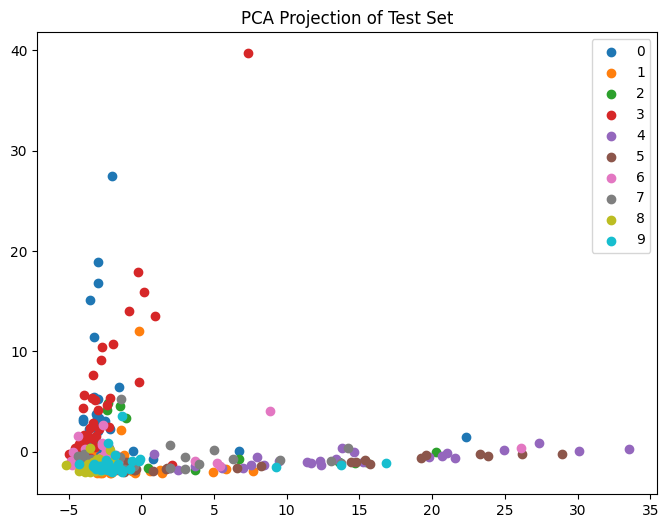

[t-SNE] Silhouette Score: -0.1271


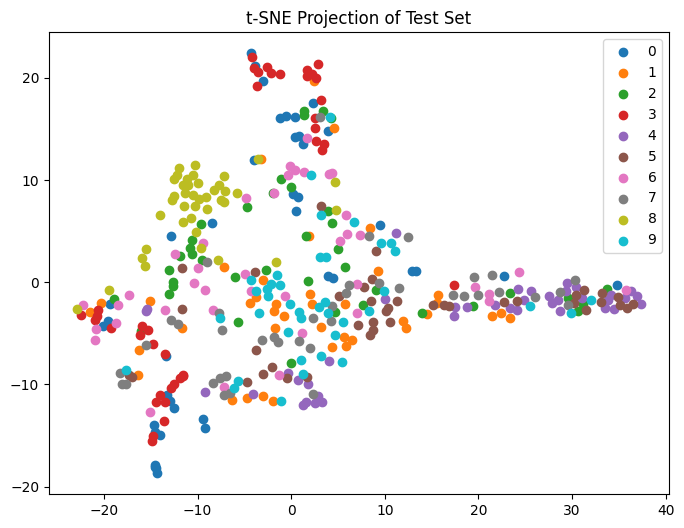

In [31]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
import torchvision.transforms as T
from torchvision.models import densenet121
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import umap
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import numpy as np
import os


# Config
class CFG:
    OUT_DIR = "/kaggle/working/prdb_ssl"  # replace with your working directory
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    BATCH_SIZE = 32
    IMG_SIZE = 224

device = CFG.DEVICE
print("[INFO] Using device:", device)


# Dataset / DataLoader
transform = T.Compose([
    T.Resize((CFG.IMG_SIZE, CFG.IMG_SIZE)),
    T.ToTensor(),
])

train_dataset = ImageFolder(root=os.path.join(CFG.OUT_DIR, "split_data/train"), transform=transform)
val_dataset   = ImageFolder(root=os.path.join(CFG.OUT_DIR, "split_data/val"), transform=transform)
test_dataset  = ImageFolder(root=os.path.join(CFG.OUT_DIR, "split_data/test"), transform=transform)

train_loader = DataLoader(train_dataset, batch_size=CFG.BATCH_SIZE, shuffle=False)
val_loader   = DataLoader(val_dataset, batch_size=CFG.BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=CFG.BATCH_SIZE, shuffle=False)

# Define EncoderOnly
class DenseNet121WithProj(nn.Module):
    def __init__(self, proj_dim=128, hidden_dim=512, pretrained=False):
        super().__init__()
        self.backbone = densenet121(weights=None)
        self.backbone.classifier = nn.Identity()
        self.proj_head = nn.Sequential(
            nn.Linear(1024, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, proj_dim)
        )

    def forward(self, x):
        features = self.backbone.features(x)
        out = F.relu(features)
        out = F.adaptive_avg_pool2d(out, (1,1))
        out = torch.flatten(out, 1)
        z = self.proj_head(out)
        return out, z

class EncoderOnly(nn.Module):
    def __init__(self, backbone):
        super().__init__()
        self.encoder = backbone.backbone if hasattr(backbone, 'backbone') else backbone
        for p in self.encoder.parameters():
            p.requires_grad = False

    def forward(self, x):
        with torch.no_grad():
            features = self.encoder.features(x)
            out = F.relu(features)
            out = F.adaptive_avg_pool2d(out, (1,1))
            out = torch.flatten(out, 1)
        return out


# Load frozen encoder
encoder_model = EncoderOnly(DenseNet121WithProj())
encoder_ckpt_path = os.path.join(CFG.OUT_DIR, "encoder_frozen_densenet121.pth")
encoder_model.load_state_dict(torch.load(encoder_ckpt_path, map_location=device))
encoder_model = encoder_model.to(device)
encoder_model.eval()


# Feature Extraction
def extract_features(loader, encoder):
    feats_list, labels_list = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            feats = encoder(imgs)
            feats_list.append(feats.cpu().numpy())
            labels_list.append(labels.numpy())
    X = np.vstack(feats_list)
    y = np.concatenate(labels_list)
    return X, y

X_test, y_test = extract_features(test_loader, encoder_model)
print(f"[INFO] Extracted {X_test.shape[0]} features of dimension {X_test.shape[1]}")


# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_test)
sil_pca = silhouette_score(X_pca, y_test)
print(f"[PCA] Silhouette Score: {sil_pca:.4f}")

plt.figure(figsize=(8,6))
for lbl in np.unique(y_test):
    plt.scatter(X_pca[y_test==lbl,0], X_pca[y_test==lbl,1], label=f"{lbl}")
plt.title("PCA Projection of Test Set")
plt.legend()
plt.show()


# t-SNE
tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42)
X_tsne = tsne.fit_transform(X_test)
sil_tsne = silhouette_score(X_tsne, y_test)
print(f"[t-SNE] Silhouette Score: {sil_tsne:.4f}")

plt.figure(figsize=(8,6))
for lbl in np.unique(y_test):
    plt.scatter(X_tsne[y_test==lbl,0], X_tsne[y_test==lbl,1], label=f"{lbl}")
plt.title("t-SNE Projection of Test Set")
plt.legend()
plt.show()

